In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df= pd.read_csv('mouse_viral_study.csv')
df.head()

,Med_1_mL,Med_2_mL,Virus Present
0,6.508231,8.582531,0
1,4.126116,3.073459,1
2,6.427870,6.369758,0
3,3.672953,4.905215,1
4,1.580321,2.440562,1


In [5]:
df.columns

Index(['Med_1_mL', 'Med_2_mL', 'Virus Present'], dtype='object')

<Axes: xlabel='Med_1_mL', ylabel='Med_2_mL'>

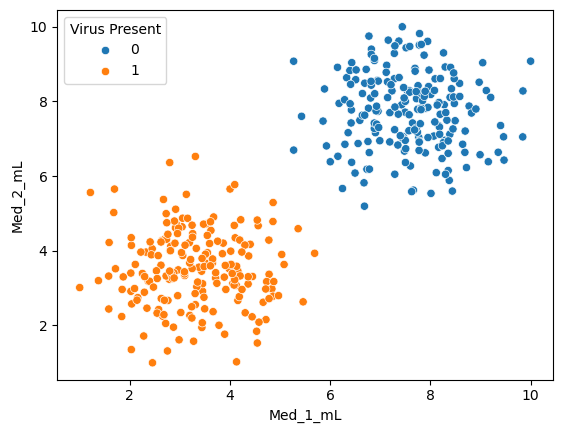

In [6]:
sns.scatterplot(x='Med_1_mL', y='Med_2_mL', hue='Virus Present', data=df)

In [7]:
from svm_margin_plot import plot_svm_boundary

In [8]:
from sklearn.svm import SVC

In [9]:
X= df.drop('Virus Present', axis=1)
y= df['Virus Present']

In [10]:
model= SVC(kernel='linear',C=1000)
model.fit(X,y)

SVC(C=1000, kernel='linear')

C:\Users\Taneja\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


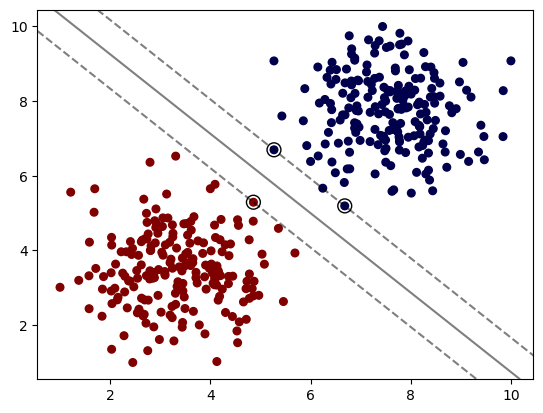

In [11]:
plot_svm_boundary(model=model,X=X,y=y)

In [13]:
# note that lower the value of C, more no. of points will be there inside the margin, check for C=0.001 and C=1000

### RBF(kernel)

C:\Users\Taneja\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


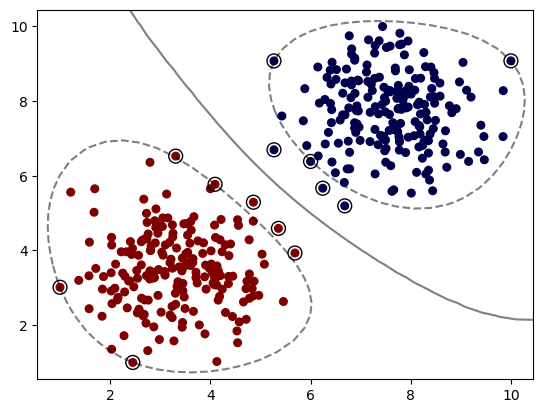

In [18]:
rbf_model= SVC(kernel= 'rbf',C=1)
rbf_model.fit(X,y)
plot_svm_boundary(model= rbf_model,X=X,y=y)

In [17]:
# note that as we decrease C the amount of misclassification inreases, check for C=1 and C=0.1 and C=0.01

In [19]:
help(SVC)

Help on class SVC in module sklearn.svm._classes:

class SVC(sklearn.svm._base.BaseSVC)
 |  SVC(
 |      *,
 |      C=1.0,
 |      kernel='rbf',
 |      degree=3,
 |      gamma='scale',
 |      coef0=0.0,
 |      shrinking=True,
 |      probability=False,
 |      tol=0.001,
 |      cache_size=200,
 |      class_weight=None,
 |      verbose=False,
 |      max_iter=-1,
 |      decision_function_shape='ovr',
 |      break_ties=False,
 |      random_state=None
 |  )
 |
 |  C-Support Vector Classification.
 |
 |  The implementation is based on libsvm. The fit time scales at least
 |  quadratically with the number of samples and may be impractical
 |  beyond tens of thousands of samples. For large datasets
 |  consider using :class:`~sklearn.svm.LinearSVC` or
 |  :class:`~sklearn.linear_model.SGDClassifier` instead, possibly after a
 |  :class:`~sklearn.kernel_approximation.Nystroem` transformer or
 |  other :ref:`kernel_approximation`.
 |
 |  The multiclass support is handled according to a

C:\Users\Taneja\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


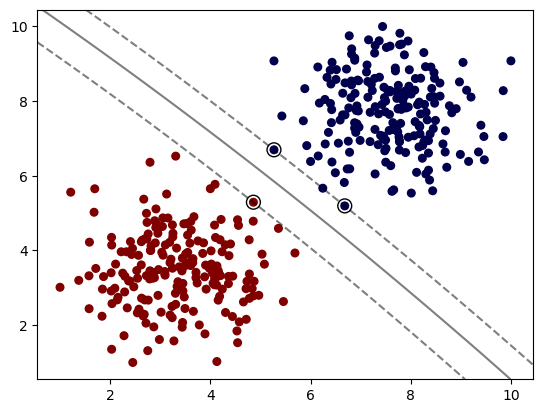

In [21]:
rbf_model= SVC(kernel= 'poly',C=1,degree=3)
rbf_model.fit(X,y)
plot_svm_boundary(model= rbf_model,X=X,y=y)

In [22]:
# note that if we put degree=2 in above then we'll get straight line

C:\Users\Taneja\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


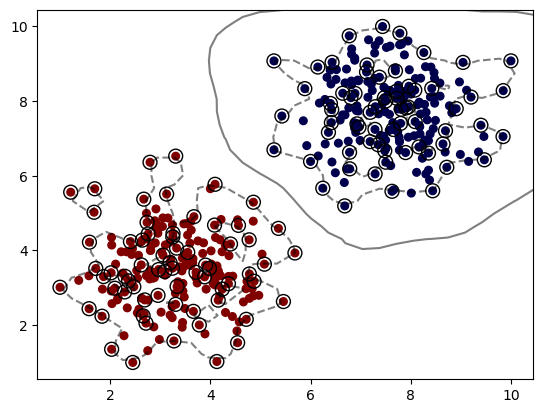

In [26]:
rbf_model= SVC(kernel= 'rbf',C=1,gamma=2)
rbf_model.fit(X,y)
plot_svm_boundary(model= rbf_model,X=X,y=y)

### Grid Search

In [27]:
from sklearn.model_selection import GridSearchCV

In [31]:
svm=SVC()
param_grid= {'C':[0.01,0.1,1,1.5],
             'kernel':['linear','rbf']}
grid= GridSearchCV(svm,param_grid)

In [32]:
grid.fit(X,y)

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.01, 0.1, 1, 1.5], 'kernel': ['linear', 'rbf']})

In [34]:
grid.best_params_

{'C': 0.01, 'kernel': 'linear'}